In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ll_df = pd.read_excel("/content/drive/My Drive/Colab Notebooks/cases_rainfall_data/LL cholera Nationale 2017_2024 ANCIEN.xlsx")
ll_df.head()

,N° ID,Epiweek date notification,Epiweek date symptoms,Phone number,Age (year),Sex,Profession,Village/Quarter,Health area of origin,Health district of origin,...,"Outcome (2=Healed, 3=Dead)","Observations (Facteur de risque : 1=eau; 2=assainissement; 3= hygiène; 4= autres saison, surpeuplement, déplacement,,,,)",Region,Commentaires,tests_+,TDR+,Delai detection,Delai notification,Unnamed: 38,ANNEES DE NOTIFICATION
0,NaN,S28_2018,S28_2018,NaN,50,F,NaN,Akok-ndoe,MBALLA 5,DJOUNGOLO,...,3,NaN,Centre,NaN,NaN,NaN,NaN,NaN,NaN,2018.0
1,NaN,S28_2018,S28_2018,NaN,34,F,NaN,"Bloc 8, Jouvence",NKOMO,ODZA,...,2,NaN,Centre,NaN,NaN,NaN,NaN,NaN,NaN,2018.0
2,NaN,S28_2018,S28_2018,NaN,68,F,NaN,Nkozoa,Monatele,MONATELE,...,2,NaN,Centre,NaN,NaN,NaN,NaN,NaN,NaN,2018.0
3,NaN,S28_2018,S28_2018,NaN,1.2,M,NaN,Essomba,Ahala 1,EFOULAN,...,2,NaN,Centre,NaN,NaN,NaN,NaN,NaN,NaN,2018.0
4,NaN,S28_2018,S28_2018,NaN,50,F,NaN,Briqueterie,Ekoudou,CITE VERTE,...,2,NaN,Centre,NaN,NaN,NaN,NaN,NaN,NaN,2018.0


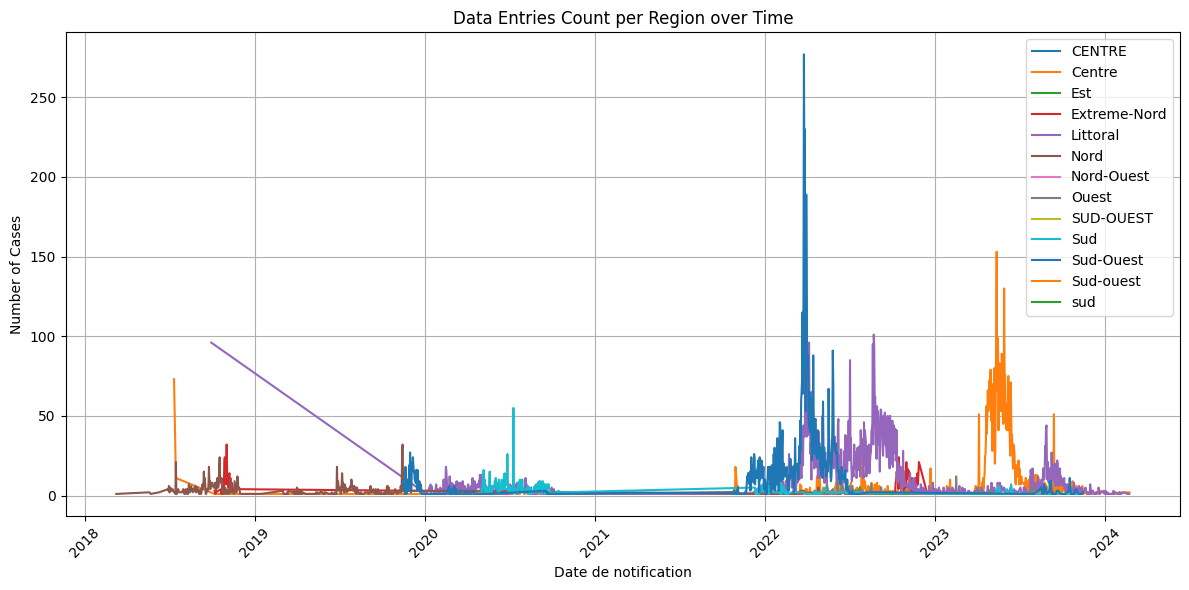

In [4]:
# prompt: plot the data entries count per region over time (Date of notification) for the ll_df

import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'll_df' is your DataFrame and it has columns named 'Date de notification' and 'Region'
# Replace with your actual column names if different

# Convert the date column to datetime objects
ll_df['Date of notification'] = pd.to_datetime(ll_df['Date of notification'])

# Group data by region and date, then count entries
entries_by_region_date = ll_df.groupby(['Region', 'Date of notification'])['Date of notification'].count().reset_index(name='Cases')

# Create the plot
plt.figure(figsize=(12, 6))

for region in entries_by_region_date['Region'].unique():
    region_data = entries_by_region_date[entries_by_region_date['Region'] == region]
    plt.plot(region_data['Date of notification'], region_data['Cases'], label=region)

plt.xlabel('Date de notification')
plt.ylabel('Number of Cases')
plt.title('Data Entries Count per Region over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
incidence_df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/cases_rainfall_data/District_Incidence.csv")

In [6]:
incidence_df.head()

,start_date,end_date,NOM_REGION,DISTRICT_S,cases,deaths
0,29/10/2021,01/11/2021,Centre,Biyem-Assi,32,1
1,29/10/2021,01/11/2021,Sud-Ouest,Ekondo Titi,23,3
2,02/11/2021,11/11/2021,Centre,Biyem-Assi,40,0
3,02/11/2021,11/11/2021,Centre,Efoulan,3,0
4,02/11/2021,11/11/2021,Centre,Mfou,1,0


<ipython-input-7-7093eb71603b>:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])


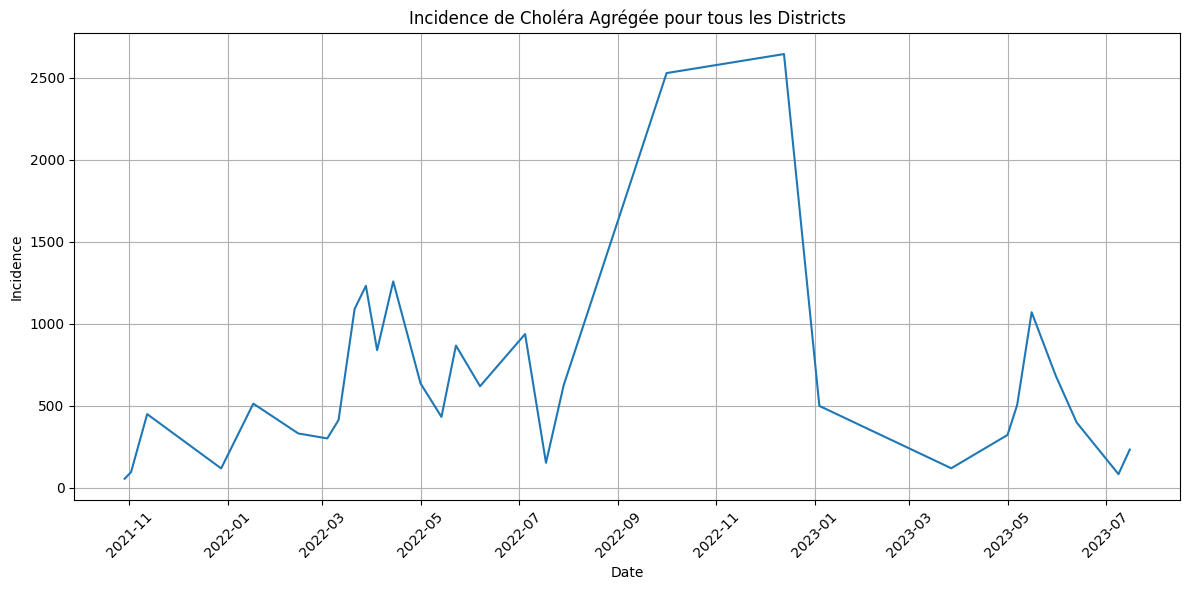

In [7]:
# prompt: create a plot of incidence data on a timeline of start_date

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and already loaded
# If not, load your data here:
# df = pd.read_excel(...)

# Assuming 'start_date' is your date column and 'incidence' is your incidence data column.
# Replace with your actual column names

# Convert the start_date column to datetime objects if it's not already.
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Group data by start_date and sum incidence for each date (or use another aggregation like mean)
incidence_by_date = incidence_df.groupby('start_date')['cases'].sum()

plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.plot(incidence_by_date.index, incidence_by_date.values)
plt.xlabel('Date')
plt.ylabel('Incidence')
plt.title('Incidence de Choléra Agrégée pour tous les Districts')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

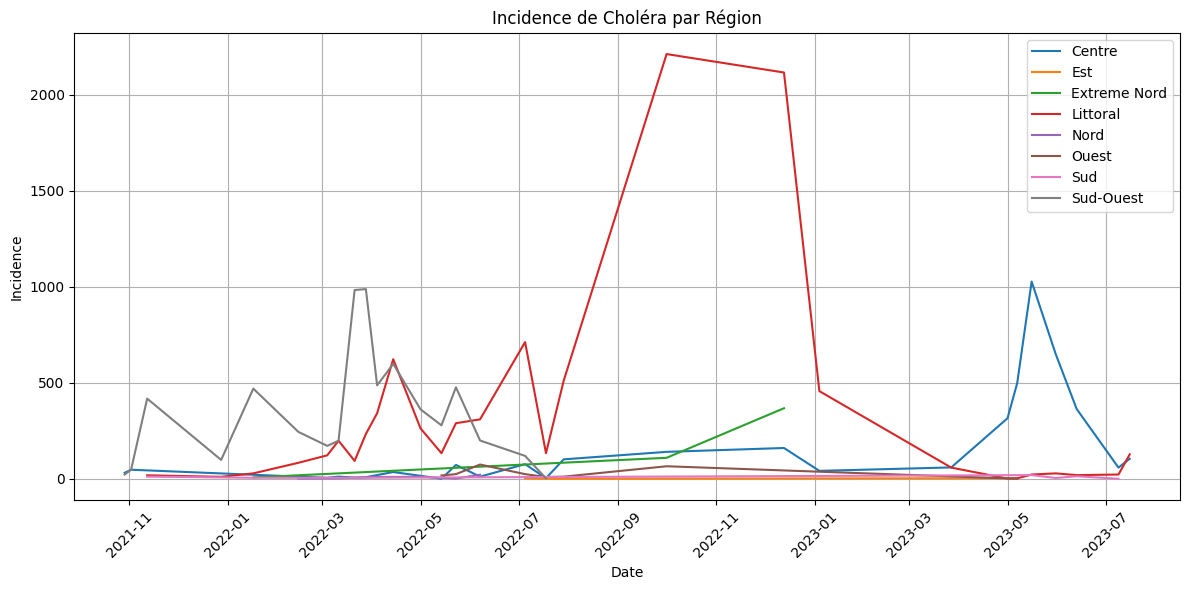

In [8]:
# prompt: create plot of incidence data per region

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'incidence_df' and already loaded
# If not, load your data here:
# incidence_df = pd.read_csv(...)

# Assuming 'start_date' is your date column, 'region' is your region column, and 'cases' is your incidence data column.
# Replace with your actual column names

# Convert the start_date column to datetime objects if it's not already.
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Group data by region and start_date, then sum incidence for each region on each date
incidence_by_region_date = incidence_df.groupby(['NOM_REGION', 'start_date'])['cases'].sum().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))

for region in incidence_by_region_date['NOM_REGION'].unique():
    region_data = incidence_by_region_date[incidence_by_region_date['NOM_REGION'] == region]
    plt.plot(region_data['start_date'], region_data['cases'], label=region)

plt.xlabel('Date')
plt.ylabel('Incidence')
plt.title('Incidence de Choléra par Région')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()  # Add a legend to identify each region's line
plt.tight_layout()
plt.show()

<ipython-input-9-d53c89de6c23>:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


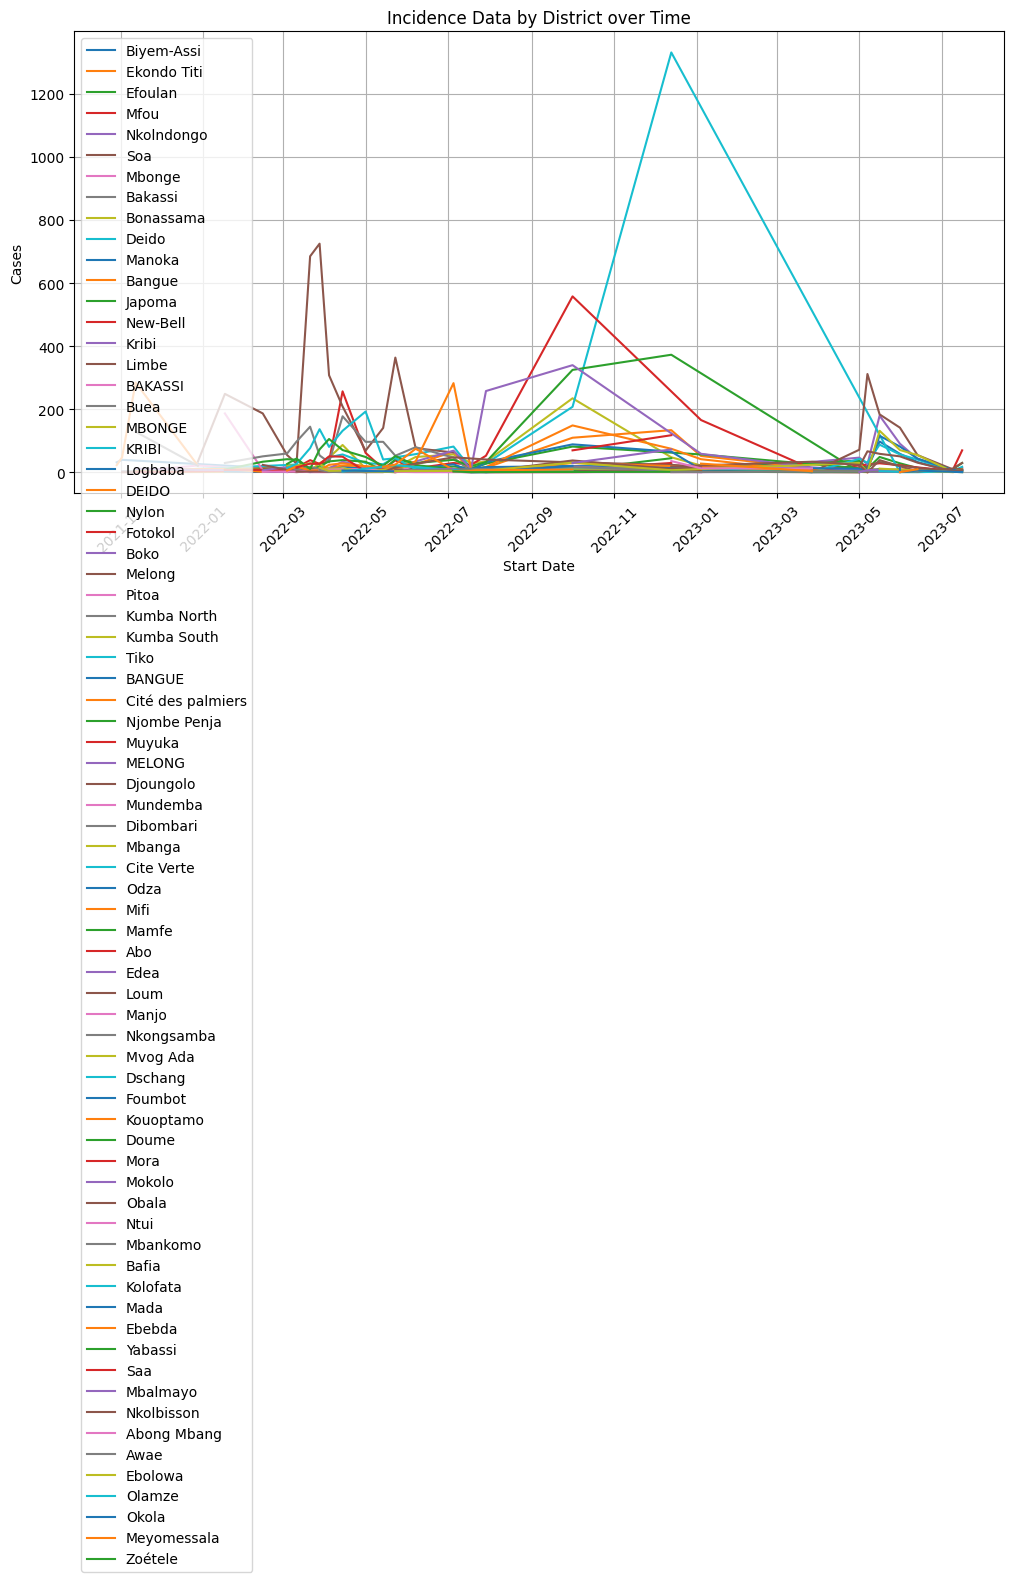

In [9]:
# prompt: create a plot of incidence data on a timeline of start_date by district cases on y axis, districts as not cumulated to sum per district

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your incidence data is in 'incidence_df'
# and 'start_date' and 'cases' are the relevant columns.

# Convert 'start_date' to datetime objects if needed
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Create the plot
plt.figure(figsize=(12, 6))

for district in incidence_df['DISTRICT_S'].unique():
    district_data = incidence_df[incidence_df['DISTRICT_S'] == district]
    plt.plot(district_data['start_date'], district_data['cases'], label=district)

plt.xlabel('Start Date')
plt.ylabel('Cases')
plt.title('Incidence Data by District over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()  # Show the legend for districts
plt.tight_layout()
plt.show()

In [10]:
ll_df.columns

Index(['N° ID', 'Epiweek date notification', 'Epiweek date symptoms',
       'Phone number', 'Age (year)', 'Sex', 'Profession', 'Village/Quarter',
       'Health area of origin', 'Health district of origin',
       'Health area notifying', 'Health district notifying',
       'Diarrhoea (Oui/Non)', 'Vomitting (Oui/Non)',
       'State of Dehydratation (1:Mild, 2:Moderate, 3:Severe)',
       'Date of onset of symptoms', 'Date of consultation',
       'Date of notification', 'Hospitalisation (Oui/Non)',
       'Date of hospitalisation', 'Site of case management',
       'Treatment ORS (Oui/No)', 'Treatment Antibiotic (Oui/No)',
       'Treatment IV liquid (Oui/No)', 'Treatment Zinc (Oui/No)',
       'Date of sample collection', 'Result of RDT', 'Culture (Oui/No)',
       'Result of culture', 'Date of discharge', 'Outcome (2=Healed, 3=Dead)',
       'Observations (Facteur de risque : 1=eau; 2=assainissement; 3= hygiène; 4= autres saison, surpeuplement, déplacement,,,,)',
       'Region', '

In [11]:
# prompt: list for every district the number of cases detected on a start_date is greater than 5  and when the previous cases for a start_date was 0 and plot the number of districts reaching the condition on a graph over time colour coded by region

# Convert 'start_date' to datetime if it's not already
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Sort the DataFrame by 'start_date' and 'DISTRICT_S' for correct lagging
incidence_df = incidence_df.sort_values(['DISTRICT_S', 'start_date'])

# Calculate the previous day's cases for each district
incidence_df['cumulative_cases_before_date'] = incidence_df.groupby('DISTRICT_S')['cases'].cumsum() - incidence_df['cases']

In [12]:
incidence_df

,start_date,end_date,NOM_REGION,DISTRICT_S,cases,deaths,cumulative_cases_before_date
216,2022-05-23,06/06/2022,Littoral,Abo,1,0,0
248,2022-06-07,20/06/2022,Littoral,Abo,6,0,1
323,2022-07-29,10/08/2022,Littoral,Abo,1,0,7
348,2022-10-01,20/10/2022,Littoral,Abo,1,0,8
408,2023-01-04,07/02/2023,Littoral,Abo,4,0,9
...,...,...,...,...,...,...,...
214,2022-05-23,06/06/2022,Sud-Ouest,Tiko,45,6,702
246,2022-06-07,20/06/2022,Sud-Ouest,Tiko,10,0,747
270,2022-07-05,17/07/2022,Sud-Ouest,Tiko,10,0,757
422,2023-01-04,07/02/2023,Littoral,Yabassi,2,0,0


In [13]:
# Identify districts where cases > 5 and previous cases were 0
triggered_df = incidence_df[(incidence_df['cases'] > 5) & (incidence_df['cumulative_cases_before_date'] == 0)]
# Remove districts where cases are already present on the first date available, epidemic found already be in process
triggered_df = triggered_df[triggered_df['start_date']> pd.Timestamp("2021-10-29")]
triggered_df

,start_date,end_date,NOM_REGION,DISTRICT_S,cases,deaths,cumulative_cases_before_date
463,2023-05-16,30/05/2023,Centre,Awae,7,0,0
24,2022-01-17,30/01/2022,Sud-Ouest,BAKASSI,187,2,0
10,2021-11-12,27/12/2021,Sud-Ouest,Bakassi,129,9,0
39,2022-02-14,20/02/2022,Littoral,Boko,7,1,0
26,2022-01-17,30/01/2022,Sud-Ouest,Buea,30,3,0
59,2022-03-04,10/03/2022,Littoral,Cité des palmiers,6,0,0
31,2022-01-17,30/01/2022,Littoral,DEIDO,11,0,0
117,2022-03-28,03/04/2022,Littoral,Dibombari,8,1,0
272,2022-07-05,17/07/2022,Ouest,Dschang,8,0,0
405,2023-01-04,07/02/2023,Centre,Ebebda,28,2,0


In [14]:
# prompt: remove any districts that appear multiple times, also if they are spelt with capitals vs lowercase

# Convert district names to lowercase for consistent comparison
triggered_df['DISTRICT_S'] = triggered_df['DISTRICT_S'].str.lower()

# Remove duplicate districts
unique_district_df = triggered_df.drop_duplicates(subset=['DISTRICT_S'])
unique_district_df

,start_date,end_date,NOM_REGION,DISTRICT_S,cases,deaths,cumulative_cases_before_date
463,2023-05-16,30/05/2023,Centre,awae,7,0,0
24,2022-01-17,30/01/2022,Sud-Ouest,bakassi,187,2,0
39,2022-02-14,20/02/2022,Littoral,boko,7,1,0
26,2022-01-17,30/01/2022,Sud-Ouest,buea,30,3,0
59,2022-03-04,10/03/2022,Littoral,cité des palmiers,6,0,0
31,2022-01-17,30/01/2022,Littoral,deido,11,0,0
117,2022-03-28,03/04/2022,Littoral,dibombari,8,1,0
272,2022-07-05,17/07/2022,Ouest,dschang,8,0,0
405,2023-01-04,07/02/2023,Centre,ebebda,28,2,0
480,2023-05-16,30/05/2023,Sud,ebolowa,12,0,0


In [15]:
len(unique_district_df)

33

<ipython-input-16-8904ddf997d6>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_district_df['start_date'] = pd.to_datetime(unique_district_df['start_date'])
<ipython-input-16-8904ddf997d6>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_district_df['NOM_REGION'].unique()))


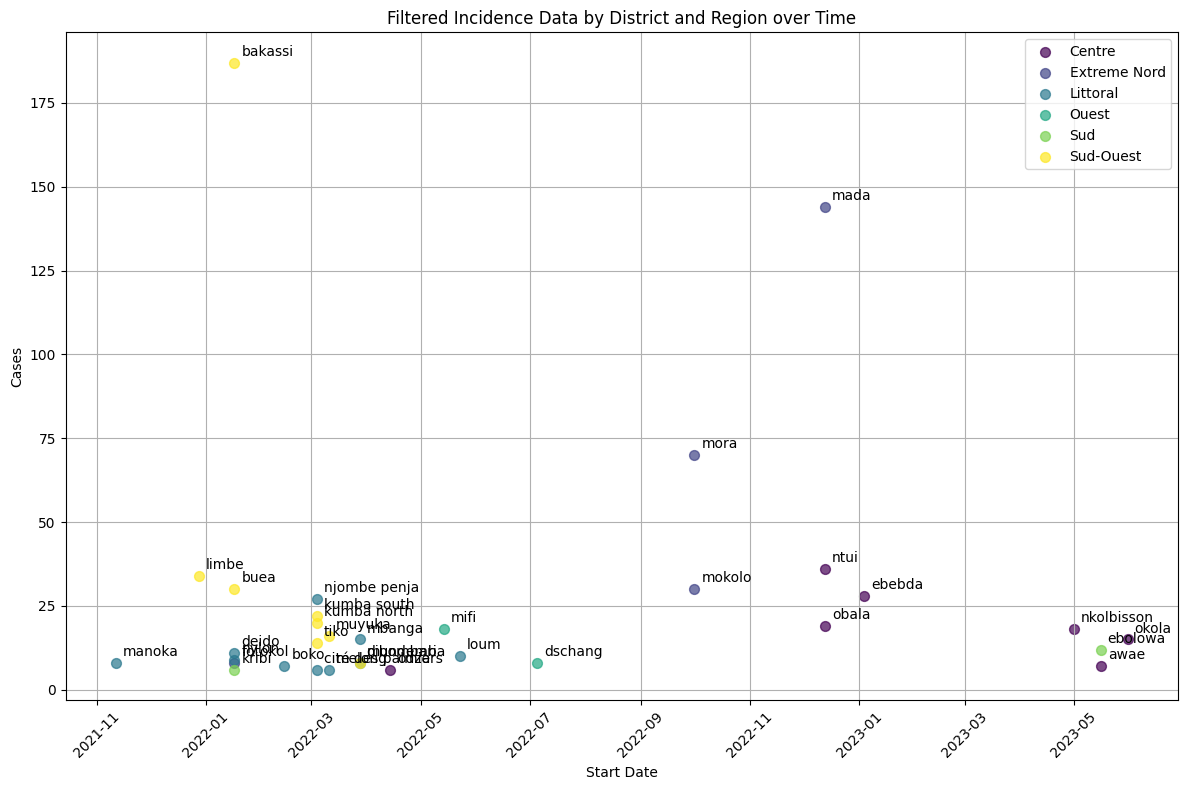

In [16]:
# prompt: plot df on scatterplot timeline colour coded by region and with the names of the districts labeled to the points

import pandas as pd
import matplotlib.pyplot as plt

# Convert 'start_date' to datetime if it's not already
unique_district_df['start_date'] = pd.to_datetime(unique_district_df['start_date'])

plt.figure(figsize=(12, 8))

# Use a colormap for regions
colors = plt.cm.get_cmap('viridis', len(unique_district_df['NOM_REGION'].unique()))

for i, (region, region_data) in enumerate(unique_district_df.groupby('NOM_REGION')):
    plt.scatter(region_data['start_date'], region_data['cases'],
                c=[colors(i)], label=region, s=50, alpha=0.7) # Adjust marker size and transparency as needed

    # Annotate each point with the district name
    for j, row in region_data.iterrows():
        plt.annotate(row['DISTRICT_S'], (row['start_date'], row['cases']), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('Start Date')
plt.ylabel('Cases')
plt.title('Filtered Incidence Data by District and Region over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# prompt: Create a list per district of all the other districts it neighbors based on the shp file
import geopandas as gpd

# Replace with your actual file path
districts_shp_file = "/content/drive/My Drive/Colab Notebooks/cases_rainfall_data/District_sante_2022.shp"

# Read the shapefile using geopandas
districts = gpd.read_file(districts_shp_file)

# Create a dictionary to store neighbor information
district_neighbors = {}

# Iterate through each district
for index, district in districts.iterrows():
    district_name = district['DISTRICT_S'].lower()
    neighbors = []

    # Iterate through all other districts
    for other_index, other_district in districts.iterrows():
      other_district_name = other_district['DISTRICT_S'].lower()
      if index != other_index and district.geometry.touches(other_district.geometry):
        neighbors.append(other_district_name)

    district_neighbors[district_name] = neighbors

# Print the neighbor list for each district
for district, neighbors in district_neighbors.items():
  print(f"District: {district}")
  print(f"Neighbors: {neighbors}")
  print("-" * 20)

District: abo
Neighbors: ['dibombari', 'mbanga', 'njombe penja', 'tiko']
--------------------
District: abong mbang
Neighbors: ['akonolinga', 'ayos', 'doume', 'lomie', 'mbang', 'messamena', 'nguelemendouka', 'yokadouma']
--------------------
District: ako
Neighbors: ['nkambe']
--------------------
District: akonolinga
Neighbors: ['abong mbang', 'awae', 'ayos', 'mbalmayo', 'mbandjock', 'messamena', 'meyomessala', 'mfou', 'zoétele']
--------------------
District: akwaya
Neighbors: ['benakuma']
--------------------
District: ambam
Neighbors: []
--------------------
District: awae
Neighbors: ['akonolinga', 'esse', 'mbandjock', 'mfou', 'soa']
--------------------
District: ayos
Neighbors: ['abong mbang', 'akonolinga', 'mbandjock', 'nanga eboko', 'nguelemendouka']
--------------------
District: bafang
Neighbors: ['baham', 'bandja', 'bangangte', 'kekem', 'melong', 'nkondjock']
--------------------
District: bafia
Neighbors: ['ebebda', 'massangam', 'monatele', 'ndikinimeki', 'ndom', 'ntui', 'y

In [18]:
# prompt: sort unique_district_df by date and print it

# Sort unique_district_df by 'start_date'
unique_district_df = unique_district_df.sort_values(by='start_date')

# Print the sorted DataFrame
unique_district_df

,start_date,end_date,NOM_REGION,DISTRICT_S,cases,deaths,cumulative_cases_before_date
13,2021-11-12,27/12/2021,Littoral,manoka,8,0,0
19,2021-12-28,04/01/2022,Sud-Ouest,limbe,34,2,0
24,2022-01-17,30/01/2022,Sud-Ouest,bakassi,187,2,0
26,2022-01-17,30/01/2022,Sud-Ouest,buea,30,3,0
31,2022-01-17,30/01/2022,Littoral,deido,11,0,0
33,2022-01-17,30/01/2022,Littoral,nylon,9,2,0
34,2022-01-17,30/01/2022,Extreme Nord,fotokol,8,0,0
28,2022-01-17,30/01/2022,Sud,kribi,6,0,0
39,2022-02-14,20/02/2022,Littoral,boko,7,1,0
51,2022-03-04,10/03/2022,Sud-Ouest,tiko,14,0,0


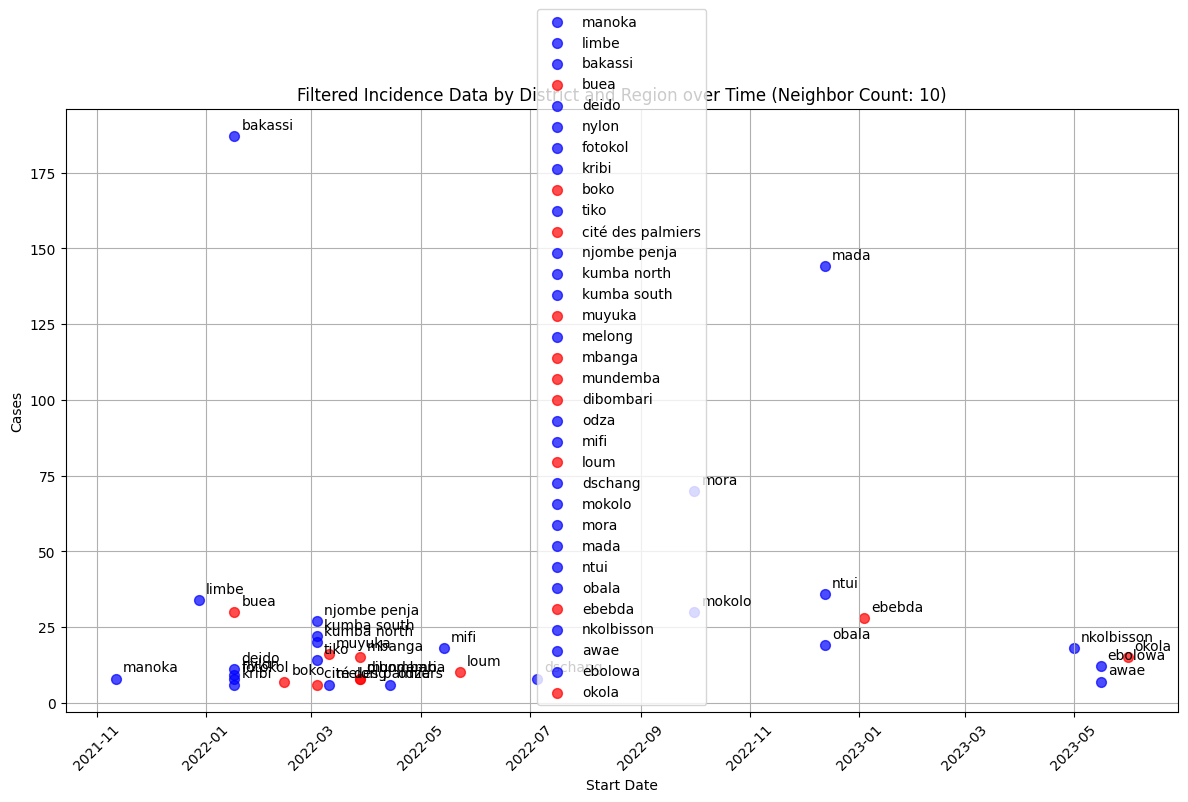

In [19]:
# prompt: remake the filtered_df scatterplot timeline but make red every district that has one of its neighbouring districts earlier in time already plotted. Then start a count

plt.figure(figsize=(12, 8))

# Create a set to store the districts that have been plotted
plotted_districts = set()
neighbor_count = 0

# Iterate through the sorted DataFrame
for index, row in unique_district_df.iterrows():
    district = row['DISTRICT_S']
    neighbors = district_neighbors.get(district, [])  # Get neighbors or empty list if not found

    color = 'blue'  # Default color
    for neighbor in neighbors:
      if neighbor.lower() in plotted_districts:
        color = 'red'
        neighbor_count +=1
        break  # Exit the inner loop if a neighbor is found in plotted_districts

    plt.scatter(row['start_date'], row['cases'], c=color, label=district if district not in plotted_districts else "", s=50, alpha=0.7)
    plotted_districts.add(district.lower())
    plt.annotate(district, (row['start_date'], row['cases']), textcoords="offset points", xytext=(5,5), ha='left')

plt.xlabel('Start Date')
plt.ylabel('Cases')
plt.title(f'Filtered Incidence Data by District and Region over Time (Neighbor Count: {neighbor_count})')
plt.grid(True)
plt.xticks(rotation=45)
# Remove duplicate labels from legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.tight_layout()
plt.show()

In [20]:
print(neighbor_count)

10
